In [1]:
# Add this at the start to mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# Then change results_dir to save to Drive:
# results_dir = "/content/drive/My Drive/thoth/research/papers/globecom26/FedAKD"

results_dir = "results"

# Imports and setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Dense, Dropout, MaxPooling1D, Conv1D, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import CSVLogger, EarlyStopping
import os
from os.path import join
import warnings
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scipy.signal import resample, savgol_filter

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# ── Shared utilities (preprocessing, models, Node classes, plotting) ──────────
from utils import (
    CLASS_NAMES,
    parse_csi_data, preprocess_csi_dataframe,
    load_homeoccupancy, load_homehar, prepare_datasets,
    split_dataset, get_model,
    Node, FedAMDNode,
    aggregate_soft_labels,
    plot_data_partitioning, plot_training_curves,
    plot_final_comparison, plot_per_client_accuracy,
)

c:\Users\ggad\Desktop\HomeSenseKD\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# GPU Configuration

# Enable GPU memory growth for efficient training
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    for device in physical_devices:
        tf.config.experimental.set_memory_growth(device, True)
print(f"GPUs available: {len(physical_devices)}")

GPUs available: 0


# Functions and classes

In [ ]:
# ── Functions now in utils.py ─────────────────────────────────────────────────
# parse_csi_data, preprocess_csi_dataframe,
# load_homeoccupancy, load_homehar, prepare_datasets,
# split_dataset, get_model, get_optimizer, remove_last_layer
# → all imported via  `from utils import ...`  in the Imports cell.

# ── Compatibility wrappers (keep original call-sites working) ─────────────────

def load_and_preprocess_homeoccupancy(window_size=100):
    """Thin wrapper around utils.load_homeoccupancy; also returns label names."""
    x_tr, y_tr, x_te, y_te = load_homeoccupancy(window_size)
    return x_tr, y_tr, x_te, y_te, CLASS_NAMES

def load_and_preprocess_homehar(window_size=100):
    """Thin wrapper around utils.load_homehar; also returns label names."""
    har_labels = ["drink", "eat", "empty", "sleep", "smoke", "watch", "work"]
    pub_x, pub_y = load_homehar(window_size)
    return pub_x, pub_y, har_labels


# ── Legacy helpers (kept for reference, not used by main flow) ────────────────

def get_data(data_dir, label, as_np=False, as_df=False):
    experiments = []
    data = []
    with open(data_dir, 'r') as f:
        for line in f.readlines():
            if line.startswith('month'):
                if len(data):
                    experiments.append(data)
                    data = []
            data.append(line)
        if len(data):
            experiments.append(data)
    if as_np or as_df:
        np_exps = []
        for exp in experiments:
            _, d = put_experiment_data_to_np(exp, label=label)
            np_exps.append(d)
        np_exp = np.concatenate(np_exps)
        if as_df:
            return pd.DataFrame({'hr': np_exp[:,0], 'gryo_x': np_exp[:,1],
                                  'gyro_y': np_exp[:,2], 'gyro_z': np_exp[:,3],
                                  'timestamp': np_exp[:,4], 'label': np_exp[:,5]})
        return np_exp
    return experiments

def put_experiment_data_to_np(exp, label=None):
    def get_first_hr(exp):
        for i in range(1, len(exp)):
            vars_ = exp[i].split(',')
            if len(vars_) == 2:
                return int(vars_[0])
    hr = get_first_hr(exp)
    np_data = []
    for i in range(1, len(exp)):
        vars_ = exp[i].split(',')
        if len(vars_) == 2:
            if int(vars_[0]) < 0: continue
            hr = (int(vars_[0]) + hr) // 2
        elif len(vars_) == 4:
            gryo_vars = list(map(int, vars_[:3]))
            data = np.array([hr, *gryo_vars, int(vars_[3].split('.')[0]),
                             *([label] if label is not None else [])])
            np_data.append(data)
    return exp[0], np.array(np_data)

def get_label(filename):
    filename = filename.split(".")[0]
    if filename.startswith('study'):  return 0
    elif filename.startswith('walk'): return 1
    elif filename.startswith('sleep'): return 2
    elif filename.startswith('idle'):  return 3
    return -1

In [ ]:
# ── Node classes now in utils.py ──────────────────────────────────────────────
# Node, FedAMDNode  →  imported via  `from utils import Node, FedAMDNode`


def number_of_parameters(model):
    return model.count_params()


def aggregate_training_metadatas(carrier_labels, target_performance, weighted_averaging=False):
    """Aggregate per-client soft labels.
    weighted_averaging=True delegates to utils.aggregate_soft_labels (accuracy-weighted).
    """
    if weighted_averaging:
        return aggregate_soft_labels(carrier_labels, target_performance)
    return np.average(carrier_labels, axis=0)


def collect_metadatas(nodes, seed, alpha):
    pub_scores, target_performances = [], []
    for node in nodes:
        tm, tp = node.get_training_metadata(seed, alpha)
        pub_scores.append(tm)
        target_performances.append(tp)
    return pub_scores, target_performances

# Data and models setup

In [6]:
experiment_dir = os.path.join(results_dir, 'exp_HomeOccupancy_FedMD')
subdirs = ['local_train_iid', 'local_train_noniid', 'central_train_iid', 'central_train_noniid', 'iid', 'noniid']
if not os.path.exists(experiment_dir):
    os.makedirs(experiment_dir)
    for subdir in subdirs : 
        os.makedirs(os.path.join(experiment_dir, subdir))


# ============ PARAMETERS FOR NEW DATASETS ============
n_parties = 20  # 20 clients as requested
n_samples_per_class = 30  # Adjusted for CSI data (fewer samples per window)
window_size = 100  # CSI window size
n_features = 52  # 52 LLTF subcarriers
input_shape = (window_size, n_features)  # (100, 52) for Conv1D
n_alignment = 1000
n_iterations = 30 

local_epochs = 4 
kd_epochs = 2

# Model configurations for 20 clients (ub, ua, dropout_rate)
models_params = [
    (10, 100, 0.1),
    (50, 100, 0.25),
    (70, 300, 0.15),
    (200, 70, 0.2),
    (128, 256, 0.1), 
    (256, 512, 0.15), 
    (93, 200, 0.25),
    (200, 400, 0.1),
    (240, 300, 0.15),
    (290, 340, 0.25),
    (10, 100, 0.1),
    (50, 100, 0.25),
    (70, 300, 0.15),
    (200, 70, 0.2),
    (128, 256, 0.1), 
    (256, 512, 0.15), 
    (93, 200, 0.25),
    (200, 400, 0.1),
    (240, 300, 0.15),
    (290, 340, 0.25)
]

print(f"Configuration: {n_parties} clients, input_shape={input_shape}, {n_iterations} iterations")

Configuration: 20 clients, input_shape=(100, 52), 30 iterations


In [7]:
# ============ LOAD PRIVATE DATASET (HomeOccupancy) ============
x_train, y_train, x_test, y_test, occupancy_label_names = load_and_preprocess_homeoccupancy(window_size=window_size)

# ============ LOAD PUBLIC DATASET (HomeHAR) ============
pub_x, pub_y, har_label_names = load_and_preprocess_homehar(window_size=window_size)

# ============ NORMALIZE ============
print("\nNormalizing data...")
# Flatten for scaling, then reshape back
train_shape = x_train.shape
test_shape = x_test.shape
pub_shape = pub_x.shape

scaling_data = MinMaxScaler()
x_train_flat = x_train.reshape(-1, n_features)
x_test_flat = x_test.reshape(-1, n_features)
pub_x_flat = pub_x.reshape(-1, n_features)

x_train_flat = scaling_data.fit_transform(x_train_flat)
x_test_flat = scaling_data.transform(x_test_flat)
pub_x_flat = scaling_data.transform(pub_x_flat)

x_train = x_train_flat.reshape(train_shape)
x_test = x_test_flat.reshape(test_shape)
pub_x = pub_x_flat.reshape(pub_shape)

# ============ SETUP LABELS ============
n_classes = 3  # HomeOccupancy has 3 classes: empty, sleep, work
original_labels = occupancy_label_names

# ============ PARTITION PRIVATE DATA OVER 10 CLIENTS ============
print("\nPartitioning private data over clients...")
pri_x_list, pri_y_list, pri_x_total, pri_y_total = split_dataset(
    x_train, y_train, 
    samples_per_class=n_samples_per_class,
    n_models=n_parties, 
    include_classes='all', 
    to_categorical_flag=True,
    n_classes_total=n_classes
)

y_train_cat = to_categorical(y_train, num_classes=n_classes)
y_test_cat = to_categorical(y_test, num_classes=n_classes)

# Shuffle data
shuffle_idx = np.random.permutation(len(x_train))
x_train = x_train[shuffle_idx]
y_train = y_train[shuffle_idx]
y_train_cat = y_train_cat[shuffle_idx]

shuffle_idx_pub = np.random.permutation(len(pub_x))
pub_x = pub_x[shuffle_idx_pub]
pub_y = pub_y[shuffle_idx_pub]

print(f'\nShape of x train data is: {x_train.shape}. Shape of y train data is: {y_train.shape}')
print(f'Shape of x test data is: {x_test.shape}. Shape of y test data is: {y_test.shape}')
print(f"Shape of x public data is: {pub_x.shape}. Shape of y public data is: {pub_y.shape}")
print(f"Single local x train is: {pri_x_list[0].shape}. Shape of single y train is: {pri_y_list[0].shape}")
print(f"\nPrivate dataset classes: {occupancy_label_names}")
print(f"Public dataset classes: {har_label_names}")

Loading HomeOccupancy dataset from HuggingFace...


  empty_1.csv: 2890 windows
  empty_2.csv: 2752 windows
  empty_3.csv (test): 2724 windows
  sleep_1.csv: 2868 windows
  sleep_2.csv: 2836 windows
  sleep_3.csv (test): 2720 windows
  work_1.csv: 1784 windows
  work_2.csv: 2633 windows
  work_3.csv (test): 2900 windows

HomeOccupancy loaded: 15763 train windows, 8344 test windows
Loading HomeHAR dataset from HuggingFace...
  data1/drink.csv: 3150 windows
  data1/eat.csv: 2974 windows
  data1/empty.csv: 2857 windows
  data1/sleep.csv: 2999 windows
  data1/smoke.csv: 2975 windows
  data1/watch.csv: 2851 windows
  data1/work.csv: 2863 windows

HomeHAR loaded: 20669 public windows

Normalizing data...

Partitioning private data over clients...

Shape of x train data is: (15763, 100, 52). Shape of y train data is: (15763,)
Shape of x test data is: (8344, 100, 52). Shape of y test data is: (8344,)
Shape of x public data is: (20669, 100, 52). Shape of y public data is: (20669,)
Single local x train is: (90, 100, 52). Shape of single y train i

# Federated learning

## i.i.d. clients

In [8]:
iid_models = [get_model(n_classes, input_shape, model_params) for model_params in models_params] 

# print data shapes
print('train_batches shape : ', x_train.shape)
print('train_labels shape : ', y_train.shape)
print('pub_data_batches shape : ', pub_x.shape)
print('pub_data_labels shape : ', pub_y.shape)
print('test_batches shape : ', x_test.shape)
print('cat_test_labels shape : ', y_test_cat.shape)

print('pri_x_list shape : ', pri_x_list[0].shape)
print('pri_y_list shape : ', pri_y_list[0].shape)
print('pri_x_total shape : ', pri_x_total.shape)
print('pri_y_total shape : ', pri_y_total.shape)

train_batches shape :  (15763, 100, 52)
train_labels shape :  (15763,)
pub_data_batches shape :  (20669, 100, 52)
pub_data_labels shape :  (20669,)
test_batches shape :  (8344, 100, 52)
cat_test_labels shape :  (8344, 3)
pri_x_list shape :  (90, 100, 52)
pri_y_list shape :  (90, 3)
pri_x_total shape :  (1800, 100, 52)
pri_y_total shape :  (1800, 3)


In [9]:


print("Local training")
# Train on own private dataset only
local_models = [get_model(n_classes, input_shape, model_params )[0] for model_params in models_params] 
for i, model in enumerate(local_models) : 
    local_training_history = model.fit(pri_x_list[i], pri_y_list[i], validation_data = (x_test, y_test_cat), epochs = 50, verbose = True)
    pd.DataFrame(local_training_history.history).to_csv(os.path.join(experiment_dir, 'local_train_iid', 'local_training_{}.csv'.format(i)))
    break 
print() 


print("central training")
# Training a model on all distributed dataset (centralized training). 
centralized_models = [get_model(n_classes, input_shape, model_params )[0] for model_params in models_params] 
for i, model in enumerate(centralized_models) : 
    centralized_training_history = model.fit(pri_x_total, pri_y_total, validation_data = (x_test, y_test_cat), epochs = 50, verbose = True)
    pd.DataFrame(centralized_training_history.history).to_csv(os.path.join(experiment_dir, 'central_train_iid', 'centralized_training_{}.csv'.format(i)))
    break 
print() 


Local training
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 701ms/step - accuracy: 0.4111 - loss: 1.0978 - val_accuracy: 0.3969 - val_loss: 1.0973
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 473ms/step - accuracy: 0.4889 - loss: 1.0975 - val_accuracy: 0.5307 - val_loss: 1.0966
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 477ms/step - accuracy: 0.4111 - loss: 1.0967 - val_accuracy: 0.5168 - val_loss: 1.0960
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 474ms/step - accuracy: 0.4444 - loss: 1.0963 - val_accuracy: 0.4688 - val_loss: 1.0954
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 473ms/step - accuracy: 0.5556 - loss: 1.0952 - val_accuracy: 0.4226 - val_loss: 1.0948
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 470ms/step - accuracy: 0.4222 - loss: 1.0950 - val_accuracy: 0.3752 - val_loss: 1.0942
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 471ms/step - accuracy: 0.4667 - loss: 1.0939 - val_accuracy: 0.3610 - val_loss: 1.0935
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 475ms/step - accuracy: 0.3667 - loss: 1.0930 - val_accuracy: 0.3

In [10]:
# Use public data for distillation (logits from models, not categorical labels)
# The public dataset has 7 classes but we use the model's output logits for distillation
shared_public_dataset = (pub_x[:n_alignment, ...], pub_y[:n_alignment, ...])
validation_dataset = (x_test, y_test_cat)
fedmd_nodes = [Node(iid_models[i], (pri_x_list[i], pri_y_list[i]), shared_public_dataset, target_validation_gen = validation_dataset) for i in range(n_parties)]

# Training iterations 
for iteration in range(n_iterations) : 
    print('\n Iteration:', iteration)

    for i, node in enumerate(fedmd_nodes) : 
        logger_file = os.path.join(experiment_dir,'iid', 'train_{}.csv'.format(i))
        node.train_on_target(epochs = local_epochs, verbose = False, logger_file = logger_file, evaluate = True)

    # seed and alpha variables are used in FedAMDNode for mixup (irrelevant for FedMD)
    seed = np.random.randint(0, 10000) 
    alpha = np.random.rand()

    pub_scores, priv_performances = collect_metadatas(fedmd_nodes, seed, alpha) 
    print("models' accuracies:", priv_performances) 
    print("Avg Acc:{} Mean:{} Std:{}".format(np.mean(priv_performances), np.mean(pub_scores), np.std(pub_scores)))
  
    # Aggregate training metadata 
    weighted_pub_scores = aggregate_training_metadatas(pub_scores, priv_performances, weighted_averaging = True) 

    # Receive training metadata (and rebuilds Carrier dataset with updated labels)
    for i, node in enumerate(fedmd_nodes) : 
        node.receive_training_metadata(weighted_pub_scores)   
        node.train_on_public(epochs = kd_epochs, verbose = False)


 Iteration: 0
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
models' accuracies: [0.44079577922821045, 0.34755513072013855, 0.7616251111030579, 0.3814717233181, 0.34755513072013855, 0.34755513072013855, 0.3292185962200165, 0.43288591504096985, 0.34419941902160645, 0

## Non-i.i.d. clients

In [11]:
## Non-i.i.d. clients

# Non-IID class distribution for 20 clients with 3 classes (empty=0, sleep=1, work=2)

parties_classes = [

    [0, 1, 2],  # Client 0: all classes

    [0, 1],     # Client 1: empty, sleep

    [1, 2],     # Client 2: sleep, work

    [0, 2],     # Client 3: empty, work

    [0, 1, 2],  # Client 4: all classes

    [0],        # Client 5: empty only

    [1],        # Client 6: sleep only

    [2],        # Client 7: work only

    [0, 1],     # Client 8: empty, sleep

    [1, 2],     # Client 9: sleep, work

    [0, 1, 2],  # Client 10: all classes

    [0, 1],     # Client 11: empty, sleep

    [1, 2],     # Client 12: sleep, work

    [0, 2],     # Client 13: empty, work

    [0, 1, 2],  # Client 14: all classes

    [0],        # Client 15: empty only

    [1],        # Client 16: sleep only

    [2],        # Client 17: work only

    [0, 1],     # Client 18: empty, sleep

    [1, 2],     # Client 19: sleep, work

]

noniid_models = [get_model(n_classes, input_shape, model_params) for model_params in models_params] 

pri_x_list_noniid, pri_y_list_noniid, pri_x_total_noniid, pri_y_total_noniid = split_dataset(

    x_train, y_train, 

    samples_per_class=n_samples_per_class,

    n_models=n_parties, 

    include_classes=parties_classes, 

    to_categorical_flag=True,

    n_classes_total=n_classes

)

# print data shapes

print('train_batches shape : ', x_train.shape)

print('train_labels shape : ', y_train.shape)

print('pub_data_batches shape : ', pub_x.shape)

print('pub_data_labels shape : ', pub_y.shape)

print('test_batches shape : ', x_test.shape)

print('categorical test_labels shape : ', y_test_cat.shape)

print("_____________________________________________")

for i in range(n_parties):

    print(f'Client {i} (classes {parties_classes[i]}): pri_x shape: {pri_x_list_noniid[i].shape}, pri_y shape: {pri_y_list_noniid[i].shape}')

print("_____________________________________________")

print('pri_x_total shape : ', pri_x_total_noniid.shape)

print('pri_y_total shape : ', pri_y_total_noniid.shape)

train_batches shape :  (15763, 100, 52)
train_labels shape :  (15763,)
pub_data_batches shape :  (20669, 100, 52)
pub_data_labels shape :  (20669,)
test_batches shape :  (8344, 100, 52)
categorical test_labels shape :  (8344, 3)
_____________________________________________
Client 0 (classes [0, 1, 2]): pri_x shape: (90, 100, 52), pri_y shape: (90, 3)
Client 1 (classes [0, 1]): pri_x shape: (60, 100, 52), pri_y shape: (60, 3)
Client 2 (classes [1, 2]): pri_x shape: (60, 100, 52), pri_y shape: (60, 3)
Client 3 (classes [0, 2]): pri_x shape: (60, 100, 52), pri_y shape: (60, 3)
Client 4 (classes [0, 1, 2]): pri_x shape: (90, 100, 52), pri_y shape: (90, 3)
Client 5 (classes [0]): pri_x shape: (30, 100, 52), pri_y shape: (30, 3)
Client 6 (classes [1]): pri_x shape: (30, 100, 52), pri_y shape: (30, 3)
Client 7 (classes [2]): pri_x shape: (30, 100, 52), pri_y shape: (30, 3)
Client 8 (classes [0, 1]): pri_x shape: (60, 100, 52), pri_y shape: (60, 3)
Client 9 (classes [1, 2]): pri_x shape: (60,

In [12]:
print("Local training")
# Train on own private dataset only
local_models = [get_model(n_classes, input_shape, model_params )[0] for model_params in models_params] 
for i, model in enumerate(local_models) : 
    local_training_history = model.fit(pri_x_list_noniid[i], pri_y_list_noniid[i], validation_data = (x_test, y_test_cat), epochs = 50, verbose = True)
    pd.DataFrame(local_training_history.history).to_csv(os.path.join(experiment_dir, 'local_train_noniid', 'local_training_{}.csv'.format(i)))
    break 

print() 
print("central training")

# Training a model on all distributed dataset (centralized training). 
centralized_models = [get_model(n_classes, input_shape, model_params )[0] for model_params in models_params] 
for i, model in enumerate(centralized_models) : 
    centralized_training_history = model.fit(pri_x_total_noniid, pri_y_total_noniid, validation_data = (x_test, y_test_cat), epochs = 50, verbose = True)
    pd.DataFrame(centralized_training_history.history).to_csv(os.path.join(experiment_dir, 'central_train_noniid', 'centralized_training_{}.csv'.format(i)))
    break 


Local training
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.3778 - loss: 1.1025 - val_accuracy: 0.3640 - val_loss: 1.0971
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 954ms/step - accuracy: 0.5222 - loss: 1.0969 - val_accuracy: 0.5240 - val_loss: 1.0945
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 910ms/step - accuracy: 0.5556 - loss: 1.0928 - val_accuracy: 0.5535 - val_loss: 1.0924
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 960ms/step - accuracy: 0.5444 - loss: 1.0881 - val_accuracy: 0.5393 - val_loss: 1.0900
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 890ms/step - accuracy: 0.5556 - loss: 1.0856 - val_accuracy: 0.5306 - val_loss: 1.0876
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.4889 - loss: 1.0806 - val_accuracy: 0.5352 - val_loss: 1.0850
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 910ms/step - accuracy: 0.4889 - loss: 1.0769 - val_accuracy: 0.5223 - val_loss: 1.0821
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 898ms/step - accuracy: 0.4889 - loss: 1.0712 - val_accuracy: 0.5077 - 

In [13]:
shared_public_dataset = (pub_x[:n_alignment, ...], pub_y[:n_alignment, ...])
validation_dataset = (x_test, y_test_cat)
fedmd_nodes = [Node(noniid_models[i], (pri_x_list_noniid[i], pri_y_list_noniid[i]), shared_public_dataset, target_validation_gen = validation_dataset) for i in range(n_parties)]

# Training iterations 
for iteration in range(n_iterations) : 
    print('\n Iteration:', iteration)

    for i, node in enumerate(fedmd_nodes) : 
        logger_file = os.path.join(experiment_dir,'noniid', 'train_{}.csv'.format(i))
        node.train_on_target(epochs = local_epochs, verbose = False, logger_file = logger_file, evaluate = True)

    # seed and alpha variables are used in FedAMDNode for mixup
    seed = np.random.randint(0, 10000) 
    alpha = np.random.rand()

    pub_scores, priv_performances = collect_metadatas(fedmd_nodes, seed, alpha) 
    print("models' accuracies:", priv_performances) 
    print("Avg Acc:{} Mean:{} Std:{}".format(np.mean(priv_performances), np.mean(pub_scores), np.std(pub_scores)))
  
    # Aggregate training metadata 
    weighted_pub_scores = aggregate_training_metadatas(pub_scores, priv_performances, weighted_averaging = True) 

    # Receive training metadata (and rebuilds Carrier dataset with updated labels)
    for i, node in enumerate(fedmd_nodes) : 
        node.receive_training_metadata(weighted_pub_scores)   
        node.train_on_public(epochs = kd_epochs, verbose = False)


 Iteration: 0
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
models' accuracies: [0.3616970181465149, 0.3259827494621277, 0.33832693099975586, 0.35498562455177307, 0.34755513072013855, 0.325263649225235, 0.22063758969306946, 0.34755513072013855, 0.326462

# Plots results 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def smooth(signal, window_len = 11, polyorder = 3) : 
    return savgol_filter(signal, window_length= window_len, polyorder = polyorder)

def get_csv_files(dir) : 
    return [join(dir, f) for f in os.listdir(dir) if f.endswith('.csv')]


class Experiment : 

    def __init__(self, root) : 
        self.root = root 
        self.colors = list(mcolors.TABLEAU_COLORS.keys())
    
    
    def get_last_accuracies (self, subdir) : 
        return [pd.read_csv(f)['val_accuracy'].values[-1] for f in get_csv_files(join(self.root, subdir))]

    def get_accuracies(self, subdir) : 
        return [pd.read_csv(f)['val_accuracy'] for f in get_csv_files(join(self.root, subdir))]
    
    def plot_fedMD_like(self, left, center, right, labels, shades = None, title = 'Accuracy', limit = None):
        assert len(left) == len(right) == len(center), 'statistics should have the same length'
        
        n_epochs = len(center[0]) 
        epochs = np.arange(n_epochs) 
        n_parties = len(center)
        if limit is None : 
            limit = n_parties 
        plt.figure(figsize=(20, 11))

        plt.subplot(2, 2, 1)
        for i in range(limit) : 
            if left is not None : 
                plt.hlines(y=left[i], xmin=-10, xmax=10, linestyle = '--', color = self.colors[i])
            if right is not None : 
                plt.hlines(y=right[i], xmin=n_epochs-10, xmax=n_epochs+10, linestyle = '--', color = self.colors[i])
            plt.plot(epochs, center[i], label=labels[i], color = self.colors[i])
            if shades is not None :
                plt.fill_between(epochs, shades[0][i], shades[1][i], alpha=0.1, color = self.colors[i])
        plt.legend(loc='best', bbox_to_anchor=(0.95, 0.5))
        plt.title(title) 
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.xlim(0, n_epochs)
        plt.show()



def plot_fedMD_like_comparison(left, center, right, labels = None, shades = None, colors = None, title = None, limit = None) :
    n_epochs = len(center[0]) 
    epochs = np.arange(n_epochs) 
    n_parties = len(center)
    if limit is None : 
        limit = n_parties 
    plt.figure(figsize=(20, 11))
    if colors is None : 
        colors = list(mcolors.TABLEAU_COLORS.keys())
    plt.subplot(2, 2, 1)
    for i in range(limit) : 
        if left is not None :
            plt.hlines(y=left[i], xmin=-10, xmax=10, linestyle = '--', color = colors[i])
        if right is not None : 
            plt.hlines(y=right[i], xmin=n_epochs-10, xmax=n_epochs+10, linestyle = '--', color = colors[i])
        plt.plot(epochs, center[i], label=labels[i], color = colors[i])
        if shades is not None :
            plt.fill_between(epochs, shades[i][0], shades[i][0], alpha=0.1, color = colors[i])
    plt.legend(loc='lower right', bbox_to_anchor=(0.95, 0.5))
    plt.title(title) 
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.xlim(0, n_epochs)
    plt.show()


Local accuracy (from CSV): 0.3476
Central accuracy (from CSV): 0.9855
models gains iid: [28, 28, 26, 28, 27, 28, 28, 28, 28, 61, 26, 28, 27, 27, 27, 63, 28, 28, 28, 26]
models gains noniid: [-2, 19, -2, -2, -2, -2, -2, -2, -2, -2, 24, -2, -2, -2, -2, -2, -2, 0, -2, -2]
20
20
20


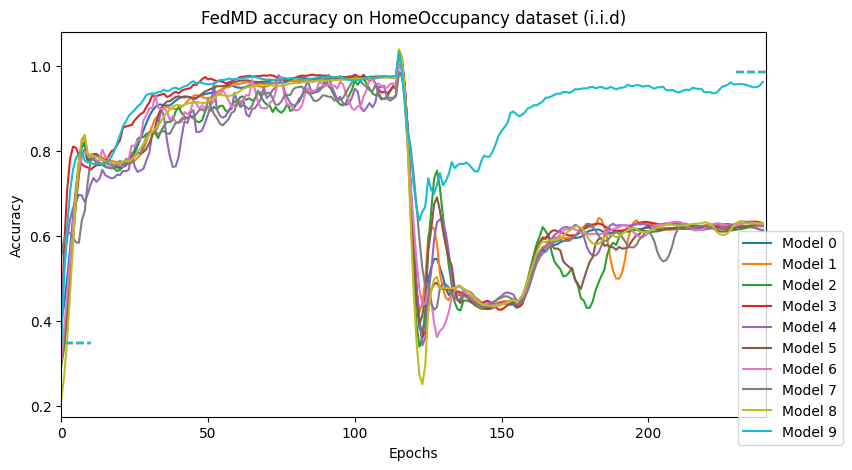

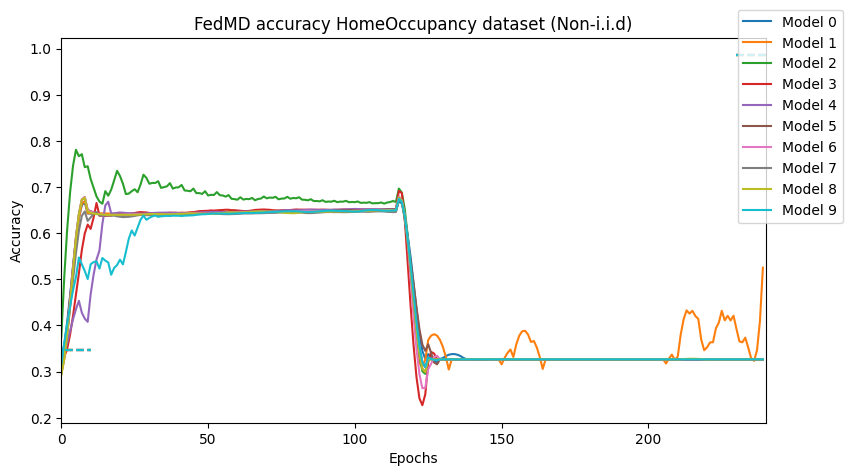

In [24]:

method = "FedMD"
vis_dir = os.path.join("results", f"exp_HomeOccupancy_{method}")  

exp = Experiment(vis_dir) 
n_parties = 20 


# Get local accuracies (use client 0's accuracy for all clients since only one was trained)
local_acc_0 = pd.read_csv(os.path.join(experiment_dir, 'local_train_iid', 'local_training_0.csv'))['val_accuracy'].iloc[-1]
last_local_accs_iid = [local_acc_0] * n_parties
last_local_accs_noniid = [local_acc_0] * n_parties  # Assuming same for non-iid
 
# Get central accuracies (use client 0's accuracy for all clients)
central_acc_0 = pd.read_csv(os.path.join(experiment_dir, 'central_train_iid', 'centralized_training_0.csv'))['val_accuracy'].iloc[-1]
last_central_accs_iid = [central_acc_0] * n_parties
last_central_accs_noniid = [central_acc_0] * n_parties  # Assuming same for non-iid
 
print(f"Local accuracy (from CSV): {local_acc_0:.4f}")
print(f"Central accuracy (from CSV): {central_acc_0:.4f}")

fed_iid = exp.get_accuracies('iid') 
fed_noniid = exp.get_accuracies('noniid') 
smooth_iid = [smooth(acc) for acc in fed_iid]
smooth_noniid = [smooth(acc) for acc in fed_noniid]

smooth_center_iid = [smooth(np.mean(fed_iid, axis = 0), window_len = 27, polyorder = 3)]
smooth_center_noniid = [smooth(np.mean(fed_noniid, axis = 0), window_len = 27, polyorder = 3)]

center_iid = [np.mean(fed_iid, axis = 0)]
center_noniid = [np.mean(fed_noniid, axis = 0)]

models_gains_iid = [int(round(fed_iid[i].values[-1] - last_local_accs_iid[i], 2) *100) for i in range(len(last_local_accs_iid))]
models_gains_noniid = [int(round(fed_noniid[i].values[-1] - last_local_accs_noniid[i], 2) *100) for i in range(len(last_local_accs_noniid))]
print('models gains iid:', models_gains_iid)
print('models gains noniid:', models_gains_noniid)








ts = [last_local_accs_iid, smooth_iid, last_central_accs_iid]
for t in ts : 
    print(len(t)) 
exp.plot_fedMD_like(last_local_accs_iid, smooth_iid, last_central_accs_iid, \
    labels = ['Model ' + str(i) for i in range(n_parties)],
     shades =None, 
     title = f'{method} accuracy on HomeOccupancy dataset (i.i.d)' , limit = 10)

exp.plot_fedMD_like(last_local_accs_noniid, smooth_noniid, last_central_accs_noniid, \
    labels = ['Model ' + str(i)  for i in range(n_parties)],
     shades =None, 
     title = f'{method} accuracy HomeOccupancy dataset (Non-i.i.d)', limit = 10)